<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Magnetic_Dipole_of_Earth_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
%%capture
!apt-get -qq update
!apt-get -qq install -y graphviz
!python -m pip -q install uv
!uv pip install --system -q graphviz pillow numpy

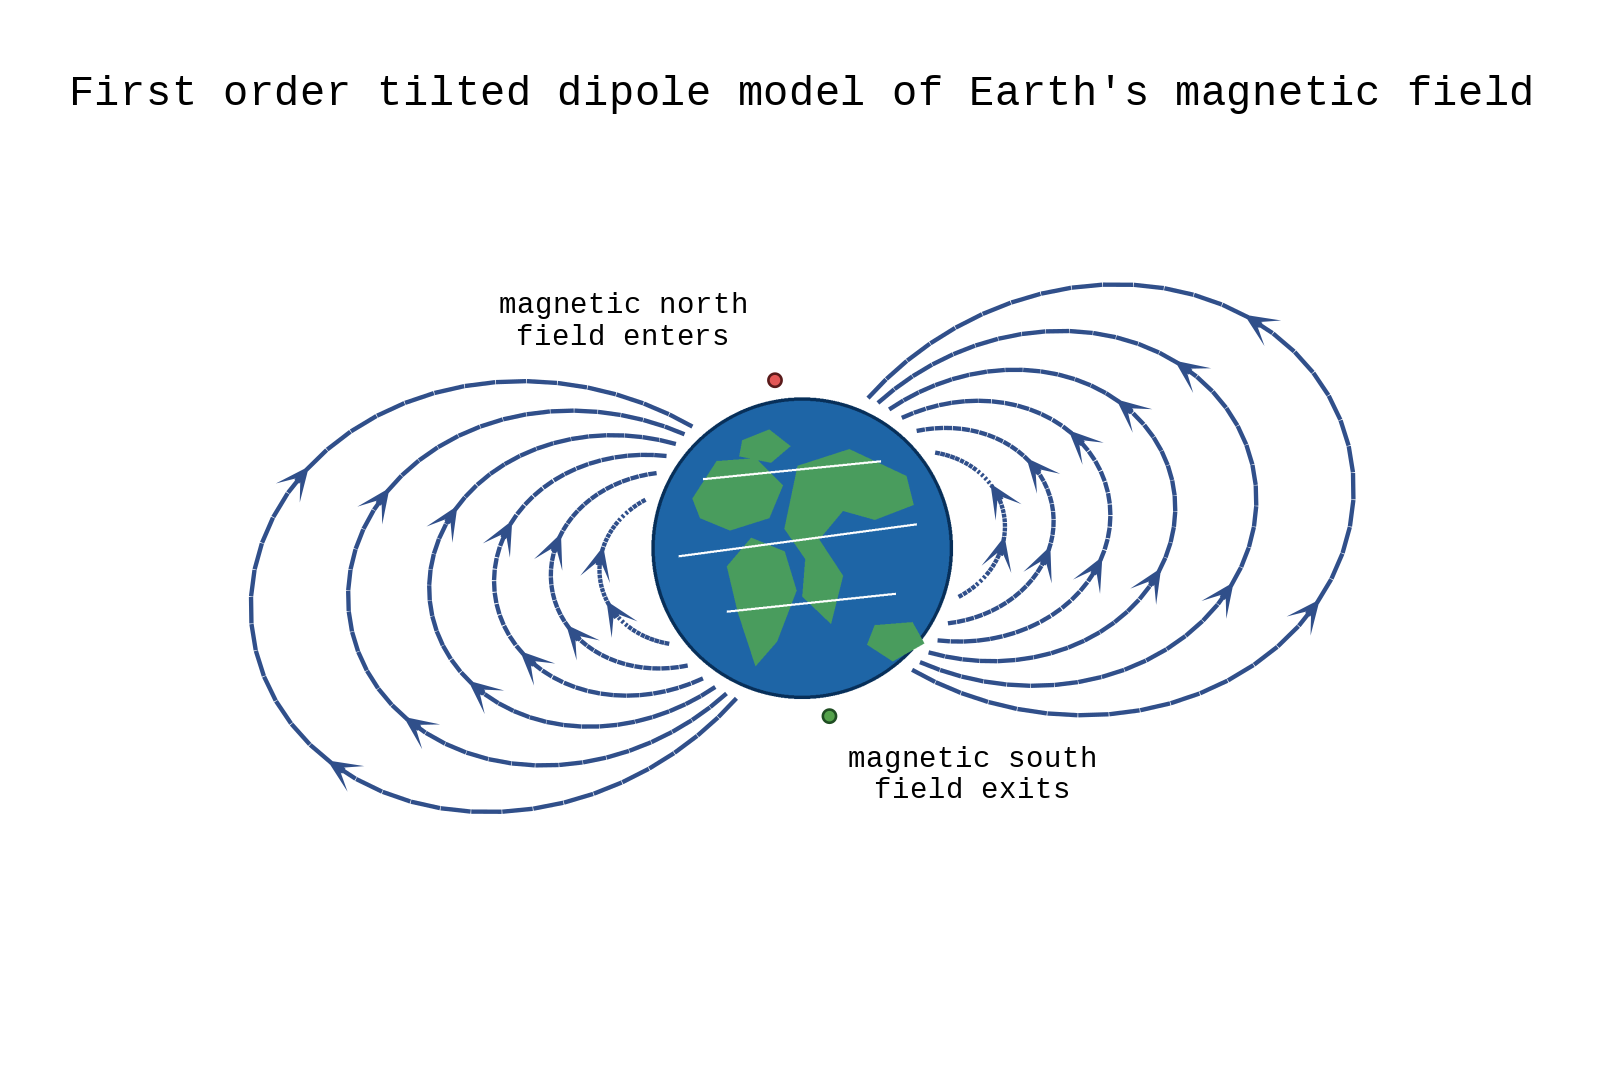

In [3]:
"""Render a tilted Earth magnetic dipole diagram with Graphviz."""

import math
from pathlib import Path
from typing import Final

import numpy as np
from graphviz import Digraph
from IPython.display import Image, display
from PIL import Image as PilImage
from PIL import ImageDraw


# Control knobs.
EARTH_ICON_PATH: Final[Path] = Path("/content/earth_icon_graphviz.png")
EARTH_RADIUS: Final[float] = 1.0
DIPOLE_TILT_DEG: Final[float] = 9.21
L_SHELL_VALUES: Final[tuple[float, ...]] = (1.25, 1.55, 1.9, 2.3, 2.8, 3.4)
POINTS_PER_FIELD_LINE: Final[int] = 42
FIELD_LINE_COLOR: Final[str] = "#304F8A"
FIELD_LINE_WIDTH: Final[float] = 1.65
EARTH_IMAGE_SIZE_PX: Final[int] = 768
MODEL_UNIT_TO_POINTS: Final[float] = 62.0
GRAPHVIZ_DPI: Final[int] = 190
CANVAS_X_LIMIT: Final[float] = 3.85
CANVAS_Y_LIMIT: Final[float] = 2.95
FONT_NAME: Final[str] = "DejaVu Sans"


def create_earth_icon(path: Path, size_px: int) -> None:
    """Create a simple Earth icon for Graphviz composition."""
    image = PilImage.new("RGBA", (size_px, size_px), (0, 0, 0, 0))
    draw = ImageDraw.Draw(image)
    center = size_px / 2.0
    radius = size_px * 0.46

    def xy(x_value: float, y_value: float) -> tuple[int, int]:
        """Map relative Earth coordinates to image pixel coordinates."""
        return (
            int(round(center + radius * x_value)),
            int(round(center - radius * y_value)),
        )

    ocean = (30, 101, 166, 255)
    land = (73, 156, 93, 255)
    edge = (7, 47, 89, 255)
    cloud = (255, 255, 255, 128)

    earth_box = (
        int(center - radius),
        int(center - radius),
        int(center + radius),
        int(center + radius),
    )
    draw.ellipse(
        earth_box,
        fill=ocean,
        outline=edge,
        width=max(2, size_px // 90),
    )

    continent_polygons = [
        [
            (-0.73, 0.33), (-0.57, 0.58), (-0.31, 0.60),
            (-0.13, 0.42), (-0.22, 0.20), (-0.48, 0.12),
            (-0.68, 0.20),
        ],
        [
            (-0.34, 0.07), (-0.12, -0.02), (-0.04, -0.28),
            (-0.17, -0.62), (-0.31, -0.78), (-0.43, -0.42),
            (-0.50, -0.12),
        ],
        [
            (-0.40, 0.72), (-0.22, 0.79), (-0.08, 0.68),
            (-0.21, 0.57), (-0.42, 0.61),
        ],
        [
            (-0.03, 0.55), (0.31, 0.66), (0.69, 0.48),
            (0.74, 0.29), (0.48, 0.19), (0.27, 0.25),
            (0.11, 0.06), (0.27, -0.18), (0.19, -0.50),
            (0.00, -0.32), (0.02, -0.07), (-0.12, 0.13),
        ],
        [
            (0.48, -0.51), (0.73, -0.49), (0.81, -0.63),
            (0.60, -0.75), (0.43, -0.64),
        ],
    ]

    for polygon in continent_polygons:
        draw.polygon(
            [xy(x_value, y_value) for x_value, y_value in polygon],
            fill=land,
        )

    cloud_lines = [
        ((-0.82, -0.05), (0.76, 0.16)),
        ((-0.66, 0.46), (0.52, 0.58)),
        ((-0.50, -0.42), (0.62, -0.30)),
    ]

    for start, end in cloud_lines:
        draw.line(
            [xy(*start), xy(*end)],
            fill=cloud,
            width=max(2, size_px // 120),
        )

    path.parent.mkdir(parents=True, exist_ok=True)
    image.save(path)


def rotate_point(
    x_value: float,
    y_value: float,
    angle_deg: float,
) -> tuple[float, float]:
    """Rotate one Cartesian point counterclockwise by angle_deg."""
    angle_rad = math.radians(angle_deg)
    cos_value = math.cos(angle_rad)
    sin_value = math.sin(angle_rad)

    return (
        x_value * cos_value - y_value * sin_value,
        x_value * sin_value + y_value * cos_value,
    )


def format_pos(x_value: float, y_value: float) -> str:
    """Return a fixed Graphviz position in points."""
    return (
        f"{x_value * MODEL_UNIT_TO_POINTS:.5f},"
        f"{y_value * MODEL_UNIT_TO_POINTS:.5f}!"
    )


def dipole_fieldline_points(
    l_shell: float,
    side: int,
    n_points: int,
    tilt_deg: float,
) -> list[tuple[float, float]]:
    """Generate one tilted 2D magnetic dipole field line outside Earth."""
    theta_foot = math.asin(math.sqrt(EARTH_RADIUS / l_shell))
    theta_values = np.linspace(math.pi - theta_foot, theta_foot, n_points)
    points = []

    for theta in theta_values:
        radius = l_shell * math.sin(theta) ** 2
        x_mag = side * radius * math.sin(theta)
        y_mag = radius * math.cos(theta)
        points.append(rotate_point(x_mag, y_mag, tilt_deg))

    return points


def add_fixed_node(
    graph: Digraph,
    name: str,
    x_value: float,
    y_value: float,
    **attributes: str,
) -> None:
    """Add a Graphviz node with a fixed position."""
    graph.node(name, pos=format_pos(x_value, y_value), pin="true", **attributes)


def add_dipole_line(
    graph: Digraph,
    name: str,
    points: list[tuple[float, float]],
) -> None:
    """Add one dipole field line as directed Graphviz segments."""
    arrow_segments = {
        max(1, int(len(points) * 0.36)),
        max(1, int(len(points) * 0.66)),
    }

    previous_node = None

    for index, (x_value, y_value) in enumerate(points):
        node_name = f"{name}_{index:03d}"
        add_fixed_node(
            graph,
            node_name,
            x_value,
            y_value,
            label="",
            shape="point",
            width="0.001",
            height="0.001",
            style="invis",
        )

        if previous_node is not None:
            graph.edge(
                previous_node,
                node_name,
                color=FIELD_LINE_COLOR,
                penwidth=f"{FIELD_LINE_WIDTH:.2f}",
                arrowsize="0.46",
                arrowhead="vee",
                dir="forward" if index in arrow_segments else "none",
            )

        previous_node = node_name


def build_diagram() -> Digraph:
    """Build the complete Graphviz diagram."""
    create_earth_icon(EARTH_ICON_PATH, EARTH_IMAGE_SIZE_PX)

    graph = Digraph("earth_magnetic_field", engine="neato", format="png")
    graph.attr(
        bgcolor="white",
        margin="0.05",
        pad="0.20",
        outputorder="edgesfirst",
        overlap="false",
        splines="line",
        start="1",
        dpi=str(GRAPHVIZ_DPI),
    )
    graph.attr("node", fontname=FONT_NAME, fontsize="11")
    graph.attr("edge", fontname=FONT_NAME)

    for corner_name, x_value, y_value in [
        ("corner_sw", -CANVAS_X_LIMIT, -CANVAS_Y_LIMIT),
        ("corner_se", CANVAS_X_LIMIT, -CANVAS_Y_LIMIT),
        ("corner_nw", -CANVAS_X_LIMIT, CANVAS_Y_LIMIT),
        ("corner_ne", CANVAS_X_LIMIT, CANVAS_Y_LIMIT),
    ]:
        add_fixed_node(
            graph,
            corner_name,
            x_value,
            y_value,
            label="",
            shape="point",
            width="0.01",
            height="0.01",
            style="invis",
        )

    for l_shell in L_SHELL_VALUES:
        for side in (-1, 1):
            points = dipole_fieldline_points(
                l_shell=l_shell,
                side=side,
                n_points=POINTS_PER_FIELD_LINE,
                tilt_deg=DIPOLE_TILT_DEG,
            )
            add_dipole_line(graph, f"L{l_shell:.2f}_{side:+d}", points)

    earth_diameter_in = 2.0 * EARTH_RADIUS * MODEL_UNIT_TO_POINTS / 72.0

    add_fixed_node(
        graph,
        "earth",
        0.0,
        0.0,
        label="",
        shape="none",
        image=str(EARTH_ICON_PATH),
        imagescale="true",
        fixedsize="true",
        width=f"{earth_diameter_in:.3f}",
        height=f"{earth_diameter_in:.3f}",
    )

    mag_north = rotate_point(0.0, 1.04 * EARTH_RADIUS, DIPOLE_TILT_DEG)
    mag_south = rotate_point(0.0, -1.04 * EARTH_RADIUS, DIPOLE_TILT_DEG)

    add_fixed_node(
        graph,
        "mag_north_marker",
        *mag_north,
        label="",
        shape="circle",
        style="filled",
        fillcolor="#E45756",
        color="#5A1A1A",
        fixedsize="true",
        width="0.075",
        height="0.075",
    )
    add_fixed_node(
        graph,
        "mag_south_marker",
        *mag_south,
        label="",
        shape="circle",
        style="filled",
        fillcolor="#54A24B",
        color="#1F4D22",
        fixedsize="true",
        width="0.075",
        height="0.075",
    )
    add_fixed_node(
        graph,
        "mag_north_label",
        mag_north[0] - 0.92,
        mag_north[1] + 0.36,
        label="magnetic north\nfield enters",
        shape="plaintext",
    )
    add_fixed_node(
        graph,
        "mag_south_label",
        mag_south[0] + 0.88,
        mag_south[1] - 0.36,
        label="magnetic south\nfield exits",
        shape="plaintext",
    )
    add_fixed_node(
        graph,
        "title",
        0.0,
        CANVAS_Y_LIMIT - 0.18,
        label="First order tilted dipole model of Earth's magnetic field",
        shape="plaintext",
        fontsize="16",
    )

    return graph


diagram = build_diagram()
png_data = diagram.pipe(format="png", neato_no_op=2)
display(Image(data=png_data))